Fingerprinting

This workbook uses a IDL_python bridge to run fingerprinting analysis on seasonal runoff data across New Zealand. It defines functions which read previously created runoff datafiles and setup the data_obs, data_scen, and noise vectors. These vectors are then input into Daithi Stone's gendetec IDL code which returns the regression coefficients for the multiple linear regression problem as follows: data_obs = beta_est * data_scen + residual. 

Results are saved in ~/figures/fingerprinting/beta_est/ if using a single truncation and ""/scan_beta_est/ if depicting a range of truncation options. 

In [34]:
import numpy as np
import pandas as pd
import xarray as xr
from functools import reduce
import matplotlib.pyplot as plt
from idlpy import *
from scipy import stats
import statsmodels.api as sm


import seaborn as sns
import cartopy.crs as ccrs

In [35]:
def get_obs_data(season, mem, resample_interval):
    
    da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_all_'+season+'_pr_gaussian_ens'+mem+'.nc')

    if resample_interval != 'annual':
        da = da.resample(time=resample_interval).mean()

    da = da.stack(pixel=("lat", "lon"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    da.close()
    
    return(array)

In [36]:
def get_mean_and_noise(season,scen, mem, resample_interval):
    
    #mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_'+scen+'_'+season+'_pr_gaussian_ensMean.nc')
    if scen == 'all':
        mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_'+scen+'_'+season+'_pr_gaussian_ensMean.nc')
    else:
        mean_for_noise = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_'+scen+'_'+season+'_pr_gaussian_ensMean.nc')

    #ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_'+scen+'_'+season+'_pr_gaussian_ensMean.nc')

    if resample_interval != 'annual':
        mean_for_noise = mean_for_noise.resample(time=resample_interval).mean()
        
    noise = []
    da_list = []
    for ens_mem in range(1,51):
        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

        if number == mem:
            continue

        if scen == 'all':
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/ECHAM5_'+scen+'_'+season+'_pr_gaussian_ens'+number+'.nc')
        else:
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/gaussian/precip/seasonal/detrend_nat/ECHAM5_'+scen+'_'+season+'_pr_gaussian_ens'+number+'.nc')

        if resample_interval != 'annual':
            mem_da = mem_da.resample(time=resample_interval).mean()
            
        diff = mem_da - mean_for_noise

        diff = diff.stack(pixel=("lat", "lon"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
        
        da_list.append(mem_da)
        
        noise.append(diff.values.flatten())

    mean_for_noise.close()

    ens_mean = sum(da_list)/len(da_list)
    ens_mean = ens_mean.stack(pixel=("lat", "lon")) # Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all") # Drop the pixels that only have NA values.
    
    ens_mean_array = ens_mean.values.flatten()
    
    ens_mean.close()
    
    return((ens_mean_array, np.array(noise)))
    #return((mean_for_noise,ens_mean, np.array(noise)))



In [28]:
mean_for_noise,mean,noise = get_mean_and_noise('winter','all', '44', '10Y')

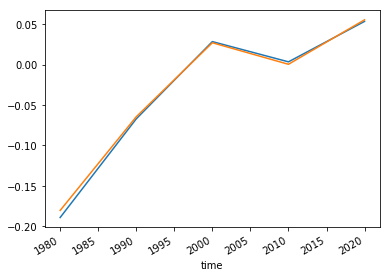

In [29]:
mean_for_noise.mean(['lat','lon']).plot()
mean.mean('pixel').plot()

In [7]:
'''
Create indivual and ensemble summary seasonal perfect model testing plots
'''

seasons = ['summer','autumn','winter','spring']

for resample_interval in ['annual','10Y','5Y']:#'annual'

    ensemble_member = []
    ant_upper = []
    ant_lower = []
    ant_best = []
    nat_upper = []
    nat_lower = []
    nat_best = []
    season = []
    for ens_mem in range(1,51):

        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

        fig,axs = plt.subplots(2,2, figsize=(12,10))#,sharey=True)
        axs = axs.flatten()

        for i,s in enumerate(seasons):    

            IDL.retall

            all_ens_mean,noise_all = get_mean_and_noise(s,'all',number,resample_interval)
            nat_ens_mean,noise_nat = get_mean_and_noise(s,'nat',number,resample_interval)

            data_obs = get_obs_data(s, number, resample_interval)

            data_scen = np.array([all_ens_mean,nat_ens_mean])

            # double noise
            #data_noise_1 = np.concatenate((noise_all,noise_nat))
            #data_noise_2 = np.concatenate((noise_all,noise_nat))
            
            data_noise_1 = np.concatenate((noise_all[:24],noise_nat[:25]))
            data_noise_2 = np.concatenate((noise_all[24:],noise_nat[25:]))
            
            trunc = np.array([i for i in range(3,48)])
            #trunc = np.array([i for i in range(3,96)])

            IDL.data_obs = data_obs
            IDL.data_scen = data_scen
            IDL.data_noise_1 = data_noise_1
            IDL.data_noise_2 = data_noise_2
            IDL.trunc = trunc
            IDL.scan_beta_est = []
            IDL.scan_p_resid = []
            IDL.scan_resid_sumsq = []
            IDL.p_resid = []
            IDL.resid_sumsq = []
            IDL.noise_singval = []
            IDL.z_best = []

            IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
                    data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
                    scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

            beta_est = IDL.beta_est
            scan_beta_est = IDL.scan_beta_est
            scan_p_resid = IDL.scan_p_resid
            scan_resid_sumsq = IDL.scan_resid_sumsq
            noise_singval = IDL.noise_singval
            z_best = IDL.z_best

            for j in range(len(scan_beta_est)):

                beta_est = scan_beta_est[j]

                best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
                best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

                axs[i].scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
                axs[i].scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

                axs[i].vlines(j+3,low_2,up_2,colors=['blue'])
                axs[i].vlines(j+3,low_1,up_1,colors=['red'])
                
                axs[i].axhline(0,-0.5,1.5)
                axs[i].axhline(1,-0.5,1.5)
                
            t = 36
            ensemble_member.append(number)
            ant_upper.append(scan_beta_est[t-3][2][0])
            ant_lower.append(scan_beta_est[t-3][1][0])
            ant_best.append(scan_beta_est[t-3][0][0])
            nat_upper.append(scan_beta_est[t-3][2][1])
            nat_lower.append(scan_beta_est[t-3][1][1])
            nat_best.append(scan_beta_est[t-3][0][1])
            season.append(s)

            axs[i].set_title(s)

            axs[i].legend()
            #axs[i].set_ylim(-4,5)

        plt.savefig('/nesi/project/niwa00015/queenle/plots/perfect_model/ECHAM5/precipitation/seasonal/'+resample_interval+'/detrend_nat_trend_all/' + 'PM_ens_' + number + '.png')

        plt.close(fig)
        
    df = pd.DataFrame({'ensemble_member':ensemble_member,
                      'season':season,
                      'ant_upper':ant_upper,
                      'ant_lower':ant_lower,
                      'ant_best':ant_best,
                      'nat_upper':nat_upper,
                      'nat_lower':nat_lower,
                      'nat_best':nat_best})

    for sort_type in ['nat_best','ant_best']:
        
        fig,axs = plt.subplots(2,2, figsize=(12,10))
        axs = axs.flatten()
        
        for i,s in enumerate(seasons):
            
            sorted_df = df.loc[df['season'] == s].sort_values(by=sort_type)
            
            axs[i].scatter([i for i in range(len(sorted_df.nat_upper))],sorted_df.nat_upper,c='blue',label='nat')
            axs[i].scatter([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,c='blue',label='')
            axs[i].scatter([i for i in range(len(sorted_df.nat_best))],sorted_df.nat_best,c='blue',label='')

            axs[i].scatter([i for i in range(len(sorted_df.ant_upper))],sorted_df.ant_upper,c='red',label='ant')
            axs[i].scatter([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,c='red',label='')
            axs[i].scatter([i for i in range(len(sorted_df.ant_best))],sorted_df.ant_best,c='red',label='')

            axs[i].vlines([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,sorted_df.nat_upper,colors=['blue'],label='')
            axs[i].vlines([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,sorted_df.ant_upper,colors=['red'],label='')

            del sorted_df
            
            axs[i].axhline(0,-0.5,1.5)
            axs[i].axhline(1,-0.5,1.5)

            axs[i].set_title(s + ', trunc = ' + str(t))

            axs[i].legend()
            
            #axs[i].set_ylim(-2,3)

        
        
        plt.savefig('/nesi/project/niwa00015/queenle/plots/perfect_model/ECHAM5/precipitation/seasonal/' + resample_interval + '/detrend_nat_trend_all/' + 'PM_ensemble_summary_'+sort_type+'_sort.png')

        plt.close(fig)
        
    del df

In [4]:
'''
Perfect model testing for EACH SEASON INDIVIDUALLY, using each ensemble member as the observations.
'''

seasons = ['summer','autumn','winter','spring']

for resample_interval in ['annual','5Y','10Y']:

    for ens_mem in range(1,51):

        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)


        fig,axs = plt.subplots(2,2, figsize=(12,10))
        axs = axs.flatten()

        for i,s in enumerate(seasons):    

            IDL.retall

            all_ens_mean,noise_all = get_mean_and_noise(s,'all',number,resample_interval)
            nat_ens_mean,noise_nat = get_mean_and_noise(s,'nat',number,resample_interval)

            data_obs = get_obs_data(s, number, resample_interval)

            data_scen = np.array([all_ens_mean,nat_ens_mean])

            data_noise_1 = np.concatenate((noise_all[:24],noise_nat[:25]))
            data_noise_2 = np.concatenate((noise_all[24:],noise_nat[25:]))


            trunc = np.array([i for i in range(3,48)])

            IDL.data_obs = data_obs
            IDL.data_scen = data_scen
            IDL.data_noise_1 = data_noise_1
            IDL.data_noise_2 = data_noise_2
            IDL.trunc = trunc
            IDL.scan_beta_est = []
            IDL.scan_p_resid = []
            IDL.scan_resid_sumsq = []
            IDL.p_resid = []
            IDL.resid_sumsq = []
            IDL.noise_singval = []
            IDL.z_best = []

            IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
                    data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
                    scan_p_resid=scan_p_resid,noise_singval=noise_singval,z_best=z_best")

            beta_est = IDL.beta_est
            scan_beta_est = IDL.scan_beta_est
            scan_p_resid = IDL.scan_p_resid
            scan_resid_sumsq = IDL.scan_resid_sumsq
            noise_singval = IDL.noise_singval
            z_best = IDL.z_best

            for j in range(len(scan_beta_est)):

                beta_est = scan_beta_est[j]

                best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
                best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

                axs[i].scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
                axs[i].scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

                axs[i].vlines(j+3,low_2,up_2,colors=['blue'])
                axs[i].vlines(j+3,low_1,up_1,colors=['red'])
                
                axs[i].axhline(0,-0.5,1.5)
                axs[i].axhline(1,-0.5,1.5)


            axs[i].set_title(s)

            axs[i].legend()

        plt.savefig('/nesi/project/niwa00015/queenle/plots/perfect_model/precipitation/seasonal/'+resample_interval+'/' + 'PM_ens_' + number + '.png')

        plt.close(fig)


In [27]:
'''
Ensemble summary at one truncation level
'''

seasons = ['summer','autumn','winter','spring']

for resample_interval in ['annual']:#'5Y','10Y',]:

    season_dfs = []
    
    for s in seasons:

        ensemble_members = []
        ant_uppers = []
        ant_lowers = []
        ant_bests = []

        nat_uppers = []
        nat_lowers = []
        nat_bests = []
        for ens_mem in range(1,51):


            number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)
            ensemble_members.append(number)

            IDL.retall

            all_ens_mean,noise_all = get_mean_and_noise(s,'all',number,resample_interval)
            nat_ens_mean,noise_nat = get_mean_and_noise(s,'nat',number,resample_interval)

            data_obs = get_obs_data(s, number, resample_interval)

            data_scen = np.array([all_ens_mean,nat_ens_mean])

            data_noise_1 = np.concatenate((noise_all[:24],noise_nat[:24]))
            data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))


            trunc = 36

            IDL.data_obs = data_obs
            IDL.data_scen = data_scen
            IDL.data_noise_1 = data_noise_1
            IDL.data_noise_2 = data_noise_2
            IDL.trunc = trunc


            IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est,\
                    data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc")

            beta_est = IDL.beta_est

            best_ant,low_ant,up_ant = beta_est[0][0],beta_est[1][0],beta_est[2][0]
            best_nat,low_nat,up_nat = beta_est[0][1],beta_est[1][1],beta_est[2][1]

            ant_uppers.append(up_ant)
            ant_lowers.append(low_ant)
            ant_bests.append(best_ant)

            nat_uppers.append(up_nat)
            nat_lowers.append(low_nat)
            nat_bests.append(best_nat)        

        df = pd.DataFrame({'ensemble_member':ensemble_members,
                          'ant_uppers':ant_uppers,
                          'ant_lowers':ant_lowers,
                          'ant_bests':ant_bests,
                          'nat_uppers':nat_uppers,
                          'nat_lowers':nat_lowers,
                          'nat_bests':nat_bests})

        season_dfs.append(df)
        
    for sort_type in ['nat_bests','ant_bests']:
        
        fig,axs = plt.subplots(2,2, figsize=(12,10))
        axs = axs.flatten()
        
        for i,s in enumerate(seasons):
            
            sorted_df = season_dfs[i].sort_values(by=sort_type)
            
            axs[i].scatter([i for i in range(len(sorted_df.nat_uppers))],sorted_df.nat_uppers,c='blue',label='nat')
            axs[i].scatter([i for i in range(len(sorted_df.nat_lowers))],sorted_df.nat_lowers,c='blue',label='')
            axs[i].scatter([i for i in range(len(sorted_df.nat_bests))],sorted_df.nat_bests,c='blue',label='')

            axs[i].scatter([i for i in range(len(sorted_df.ant_uppers))],sorted_df.ant_uppers,c='red',label='ant')
            axs[i].scatter([i for i in range(len(sorted_df.ant_lowers))],sorted_df.ant_lowers,c='red',label='')
            axs[i].scatter([i for i in range(len(sorted_df.ant_bests))],sorted_df.ant_bests,c='red',label='')

            axs[i].vlines([i for i in range(len(sorted_df.nat_lowers))],sorted_df.nat_lowers,sorted_df.nat_uppers,colors=['blue'],label='')
            axs[i].vlines([i for i in range(len(sorted_df.ant_lowers))],sorted_df.ant_lowers,sorted_df.ant_uppers,colors=['red'],label='')

            axs[i].axhline(0,-0.5,1.5)
            axs[i].axhline(1,-0.5,1.5)

            axs[i].set_title(s + ', trunc = ' + str(trunc))

            axs[i].legend()

        plt.savefig('/nesi/project/niwa00015/queenle/plots/perfect_model/ECHAM5/precipitation/seasonal/' + resample_interval + '/' + 'PM_ensemble_summary_'+sort_type+'_sort_TEST.png')

        plt.close(fig)


In [37]:
'''
Write ensemble summary csv files
'''

seasons = ['summer','autumn','winter','spring']

for resample_interval in ['annual','10Y','5Y']:

    ensemble_member = []
    ant_upper = []
    ant_lower = []
    ant_best = []
    nat_upper = []
    nat_lower = []
    nat_best = []
    season = []
    for ens_mem in range(1,51):

        number = '0' + str(ens_mem) if ens_mem < 10 else str(ens_mem)

        for i,s in enumerate(seasons):    

            IDL.retall

            all_ens_mean,noise_all = get_mean_and_noise(s,'all',number,resample_interval)
            nat_ens_mean,noise_nat = get_mean_and_noise(s,'nat',number,resample_interval)

            data_obs = get_obs_data(s, number, resample_interval)

            data_scen = np.array([all_ens_mean,nat_ens_mean])

            #data_noise_1 = np.concatenate((noise_all[:24],noise_nat[:25]))
            #data_noise_2 = np.concatenate((noise_all[24:],noise_nat[25:]))
            
            data_noise_1 = np.concatenate((noise_all[:24],noise_nat[:24]))
            data_noise_2 = np.concatenate((noise_all[25:],noise_nat[25:]))
            
            trunc = 36

            IDL.data_obs = data_obs
            IDL.data_scen = data_scen
            IDL.data_noise_1 = data_noise_1
            IDL.data_noise_2 = data_noise_2
            IDL.trunc = trunc

            IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
                    data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc")

            beta_est = IDL.beta_est

            ensemble_member.append(number)
            ant_upper.append(beta_est[2][0])
            ant_lower.append(beta_est[1][0])
            ant_best.append(beta_est[0][0])
            nat_upper.append(beta_est[2][1])
            nat_lower.append(beta_est[1][1])
            nat_best.append(beta_est[0][1])
            season.append(s)
        
    df = pd.DataFrame({'ensemble_member':ensemble_member,
                      'season':season,
                      'ant_upper':ant_upper,
                      'ant_lower':ant_lower,
                      'ant_best':ant_best,
                      'nat_upper':nat_upper,
                      'nat_lower':nat_lower,
                      'nat_best':nat_best})

    df.to_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/pr_" +resample_interval + "_trunc_" + str(trunc) + ".csv")
    
    del df

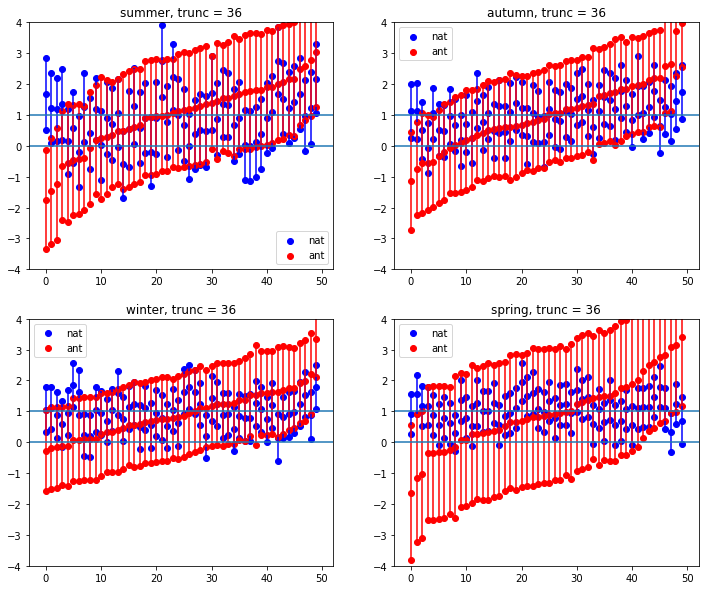

In [33]:
df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/mem_in_mean/sro_annual_trunc_36.csv")
sort_type = 'ant_best'

fig,axs = plt.subplots(2,2, figsize=(12,10))
axs = axs.flatten()

for i,s in enumerate(seasons):

    sorted_df = df.loc[df['season'] == s].sort_values(by=sort_type)

    axs[i].scatter([i for i in range(len(sorted_df.nat_upper))],sorted_df.nat_upper,c='blue',label='nat')
    axs[i].scatter([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,c='blue',label='')
    axs[i].scatter([i for i in range(len(sorted_df.nat_best))],sorted_df.nat_best,c='blue',label='')

    axs[i].scatter([i for i in range(len(sorted_df.ant_upper))],sorted_df.ant_upper,c='red',label='ant')
    axs[i].scatter([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,c='red',label='')
    axs[i].scatter([i for i in range(len(sorted_df.ant_best))],sorted_df.ant_best,c='red',label='')

    axs[i].vlines([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,sorted_df.nat_upper,colors=['blue'],label='')
    axs[i].vlines([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,sorted_df.ant_upper,colors=['red'],label='')

    axs[i].axhline(0,-0.5,1.5)
    axs[i].axhline(1,-0.5,1.5)

    axs[i].set_title(s + ', trunc = 36')

    axs[i].legend()

    axs[i].set_ylim(-4,4)

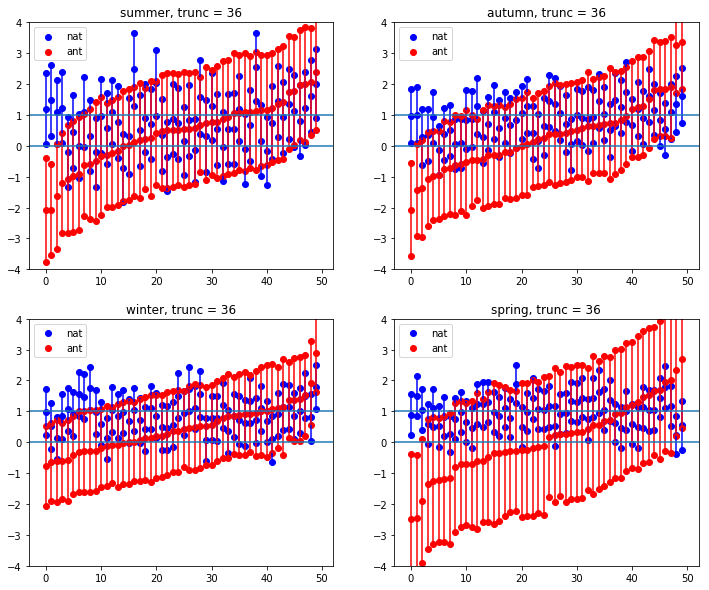

In [38]:
df = pd.read_csv("/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/ECHAM5/summary_csv/detrend_nat_trend_all/sro_annual_trunc_36.csv")
sort_type = 'ant_best'

fig,axs = plt.subplots(2,2, figsize=(12,10))
axs = axs.flatten()

for i,s in enumerate(seasons):

    sorted_df = df.loc[df['season'] == s].sort_values(by=sort_type)

    axs[i].scatter([i for i in range(len(sorted_df.nat_upper))],sorted_df.nat_upper,c='blue',label='nat')
    axs[i].scatter([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,c='blue',label='')
    axs[i].scatter([i for i in range(len(sorted_df.nat_best))],sorted_df.nat_best,c='blue',label='')

    axs[i].scatter([i for i in range(len(sorted_df.ant_upper))],sorted_df.ant_upper,c='red',label='ant')
    axs[i].scatter([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,c='red',label='')
    axs[i].scatter([i for i in range(len(sorted_df.ant_best))],sorted_df.ant_best,c='red',label='')

    axs[i].vlines([i for i in range(len(sorted_df.nat_lower))],sorted_df.nat_lower,sorted_df.nat_upper,colors=['blue'],label='')
    axs[i].vlines([i for i in range(len(sorted_df.ant_lower))],sorted_df.ant_lower,sorted_df.ant_upper,colors=['red'],label='')

    axs[i].axhline(0,-0.5,1.5)
    axs[i].axhline(1,-0.5,1.5)

    axs[i].set_title(s + ', trunc = 36')

    axs[i].legend()

    axs[i].set_ylim(-4,4)